Found subdirectories (classes): ['scratch', 'cross', 'single-line', 'zig-zag', 'Diagonal', 'wave', 'double-line']
Found 50 files belonging to 7 classes.
Dataset created with 7 classes: ['Diagonal', 'cross', 'double-line', 'scratch', 'single-line', 'wave', 'zig-zag']
Total batches: 2


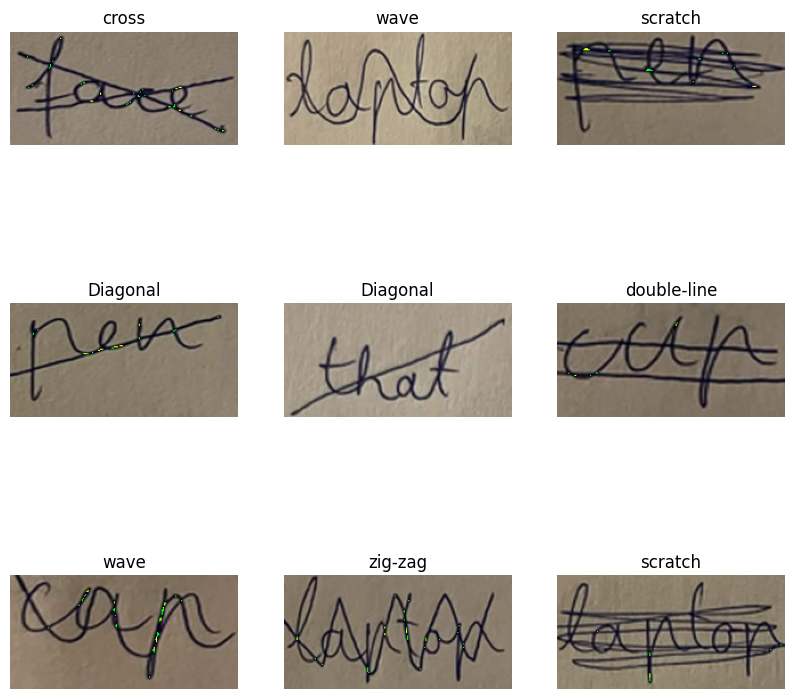

In [ ]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt

dataset_path = '/content/drive/MyDrive/img/'

if not os.path.exists(dataset_path):
    print(f"Error: Dataset path '{dataset_path}' not found.")
else:
    subdirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    if not subdirs:
        print(f"Error: No subdirectories found in '{dataset_path}'. Please ensure your images are organized into subfolders representing classes.")
    else:
        print(f"Found subdirectories (classes): {subdirs}")

        try:
            image_height = 100
            image_width = 200
            batch_size = 32

            dataset = tf.keras.utils.image_dataset_from_directory(
                dataset_path,
                labels='inferred',
                label_mode='categorical',
                image_size=(image_height, image_width),
                interpolation='lanczos3',
                batch_size=batch_size,
                shuffle=True,
                seed=42
            )

            print(f"Dataset created with {len(dataset.class_names)} classes: {dataset.class_names}")
            print(f"Total batches: {len(dataset)}")

            plt.figure(figsize=(10, 10))
            for images, labels in dataset.take(1):
                for i in range(min(9, len(images))):
                    ax = plt.subplot(3, 3, i + 1)
                    plt.imshow(images[i].numpy().astype("uint8"))
                    predicted_class_index = np.argmax(labels[i].numpy())
                    plt.title(dataset.class_names[predicted_class_index])
                    plt.axis("off")
            plt.show()

        except Exception as e:
            print(f"An error occurred while creating the dataset: {e}")


In [ ]:
dataset_size = len(dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_ds = dataset.take(train_size)
remaining_ds = dataset.skip(train_size)
val_ds = remaining_ds.take(val_size)
test_ds = remaining_ds.skip(val_size)

print(f"Dataset split into: ")
print(f"  Training: {len(train_ds)} batches")
print(f"  Validation: {len(val_ds)} batches")
print(f"  Test: {len(test_ds)} batches")


Dataset split into: 
  Training: 1 batches
  Validation: 0 batches
  Test: 1 batches


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets prepared with caching and prefetching.")


Datasets prepared with caching and prefetching.


In [ ]:
num_classes = len(dataset.class_names)

model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255, input_shape=(image_height, image_width, 3)),
  tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 100, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 200, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 100, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 100, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 19200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,457,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,482,215 (9.47 MB)

 Trainable params: 2,482,215 (9.47 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

print("Model training complete.")

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7812 - loss: 1.4905
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.8438 - loss: 1.3513
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8750 - loss: 1.1873
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step - accuracy: 0.9375 - loss: 1.0013
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step - accuracy: 1.0000 - loss: 0.7993
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step - accuracy: 1.0000 - loss: 0.6069
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step - accuracy: 1.0000 - loss: 0.4564
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step - accuracy: 1.0000 - loss: 0.3275
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step - accuracy: 1.0000 - loss: 0.1884
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step - accuracy: 1.0000 - loss: 0.1334
Model training complete.


In [30]:
print("Evaluating model on the test dataset...")
loss, accuracy = model.evaluate(test_ds)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Evaluating model on the test dataset...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6667 - loss: 0.8629
Test Loss: 0.8629
Test Accuracy: 0.6667
